# **Data Scientist**



# Pertanyaan Bisnis

1. Pada kelompok usia serta jenis kelamin manakah yang memiliki presentase stunting tertinggi ditemukan pada balita dalam rentang usia 0 sampai 24 bulan?
2. Bagaimana distribusi dan karakteristik tinggi badan, berat badan, usia, serta jenis kelamin pada masing-masing kategori status stunting balita usia 0–24 bulan?
3. Bagaimana distribusi jumlah kasus stunting pada setiap kelompok usia dan jenis kelamin balita usia 0–24 bulan dalam dataset AnakSehat AI?
4. Bagaimana hubungan antara tinggi badan, berat badan, dan usia terhadap kategori status stunting balita berdasarkan hasil visualisasi data pada dataset AnakSehat AI?
5. Bagaimana perbedaan pola pertumbuhan tinggi badan dan berat badan antara balita normal, stunted, dan severely stunted usia 0–24 bulan berdasarkan dataset AnakSehat AI?




# Import Library



In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Data Wrangling

## Gathering Data

In [ ]:
# Load dataset transaksi
file_id = "1AFog6Fgq32HfuWeCfOdikAbI_8CS9tLp"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url)

In [ ]:
df.head()

,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight
1,Laki-laki,20,77.7,8.5,Stunted,Underweight
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight


Insight Awal Dataset
Dari dataset terlihat ada:
1. Umur (bulan)
2. Tinggi badan
3. Berat badan
4. Jenis kelamin
5. Stunting
6. Wasting

## Assessing Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Jenis Kelamin      100000 non-null  object 
 1   Umur (bulan)       100000 non-null  int64  
 2   Tinggi Badan (cm)  100000 non-null  float64
 3   Berat Badan (kg)   100000 non-null  float64
 4   Stunting           100000 non-null  object 
 5   Wasting            100000 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 4.6+ MB


In [ ]:
# Cek missing value
df.isnull().sum()

,0
Jenis Kelamin,0
Umur (bulan),0
Tinggi Badan (cm),0
Berat Badan (kg),0
Stunting,0
Wasting,0


In [ ]:
# Cek duplicate
df.duplicated().sum()

np.int64(7308)

Berdasarkan hasil df.info():

Dataset memiliki 100.000 baris data dan 6 kolom

Terdapat:
- 2 kolom numerik bertipe float
- 1 kolom integer
- 3 kolom kategorikal (object)

Serta: Ditemukan 7.308 data duplikat yang berpotensi menyebabkan bias pada hasil analisis karena beberapa data tercatat lebih dari satu kali.

## Cleaning Data

In [ ]:
# Menghapus data duplikat
df = df.drop_duplicates()

In [ ]:
# Cek duplicate ulang setelah menghapus
df.duplicated().sum()

np.int64(0)

In [ ]:
# Cek kembali dataset setelah dihapus
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92692 entries, 0 to 99997
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Jenis Kelamin      92692 non-null  object 
 1   Umur (bulan)       92692 non-null  int64  
 2   Tinggi Badan (cm)  92692 non-null  float64
 3   Berat Badan (kg)   92692 non-null  float64
 4   Stunting           92692 non-null  object 
 5   Wasting            92692 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 5.0+ MB


### Re-name kolom dataset

In [ ]:
df = df.rename(columns={
    'Jenis Kelamin':'jenis_kelamin',
    'Umur (bulan)':'umur_bulan',
    'Tinggi Badan (cm)':'tinggi_cm',
    'Berat Badan (kg)':'berat_kg',
    'Stunting':'stunting',
    'Wasting':'wasting'
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92692 entries, 0 to 99997
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   jenis_kelamin  92692 non-null  object 
 1   umur_bulan     92692 non-null  int64  
 2   tinggi_cm      92692 non-null  float64
 3   berat_kg       92692 non-null  float64
 4   stunting       92692 non-null  object 
 5   wasting        92692 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 5.0+ MB


Insight Cleaning Data
1. Menghapus Data Duplikat

Sebanyak 7.308 data duplikat berhasil dihapus dari dataset. Setelah proses cleaning, jumlah data berubah dari 100.000 menjadi 92.692 baris.

Insight Penghapusan data duplikat dilakukan untuk menghindari bias pada hasil analisis serta meningkatkan kualitas dan akurasi data.

2. Re-name Kolom Dataset

Nama kolom diubah menjadi format snake_case agar lebih rapi, konsisten, dan memudahkan proses analisis maupun pemanggilan variabel pada Python.

Contoh:

Jenis Kelamin → jenis_kelamin
Umur (bulan) → umur_bulan
Insight:

Standarisasi nama kolom membantu meningkatkan keterbacaan kode dan mempermudah proses data processing selanjutnya.

# Exploratory Data Analysis (EDA)

In [ ]:
df.sample(10)

,jenis_kelamin,umur_bulan,tinggi_cm,berat_kg,stunting,wasting
95698,Perempuan,24,93.9,9.3,Normal,Underweight
77135,Perempuan,22,86.1,12.9,Normal,Risk of Overweight
84558,Perempuan,8,67.2,7.6,Normal,Normal weight
29818,Laki-laki,17,77.9,9.5,Normal,Normal weight
2456,Laki-laki,15,76.5,8.7,Normal,Normal weight
28487,Laki-laki,3,67.0,4.9,Normal,Underweight
86583,Perempuan,20,87.8,7.8,Normal,Underweight
81315,Perempuan,14,73.8,10.5,Normal,Normal weight
91776,Laki-laki,17,79.5,8.2,Normal,Underweight
11863,Perempuan,24,85.2,15.6,Normal,Risk of Overweight


In [ ]:
df.describe()

,umur_bulan,tinggi_cm,berat_kg
count,92692.000000,92692.000000,92692.000000
mean,12.166347,73.394037,9.317442
std,7.174078,11.279690,3.286822
min,0.000000,42.600000,1.000000
25%,6.000000,65.800000,6.900000
50%,12.000000,74.400000,9.200000
75%,18.000000,81.600000,11.800000
max,24.000000,97.600000,17.200000


In [ ]:
# cek distribusi kolom stunting
df['stunting'].value_counts()

,count
stunting,
Normal,67055
Stunted,15039
Severely Stunted,5333
Tall,5265


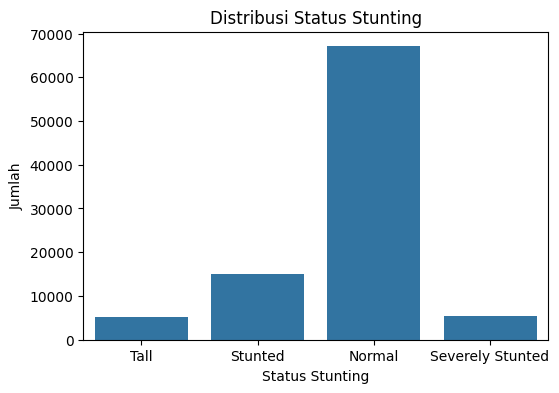

In [ ]:
# visualisasi
plt.figure(figsize=(6,4))

sns.countplot(
    x='stunting',
    data=df
)

plt.title('Distribusi Status Stunting')
plt.xlabel('Status Stunting')
plt.ylabel('Jumlah')

plt.show()

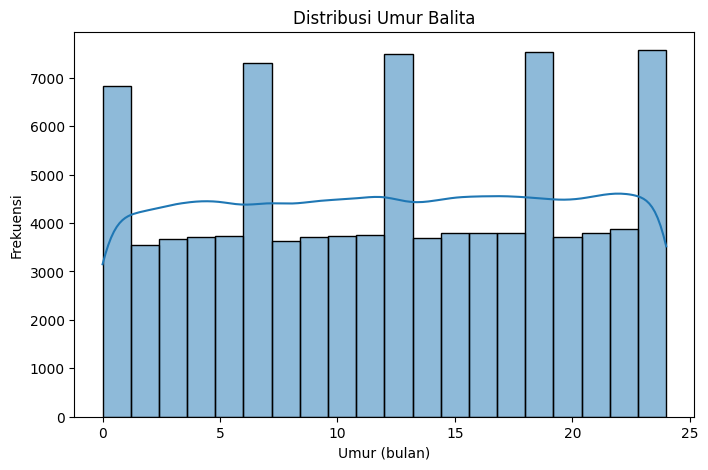

In [ ]:
# visualisasi distribusi umur
plt.figure(figsize=(8,5))

sns.histplot(
    df['umur_bulan'],
    bins=20,
    kde=True
)

plt.title('Distribusi Umur Balita')
plt.xlabel('Umur (bulan)')
plt.ylabel('Frekuensi')

plt.show()

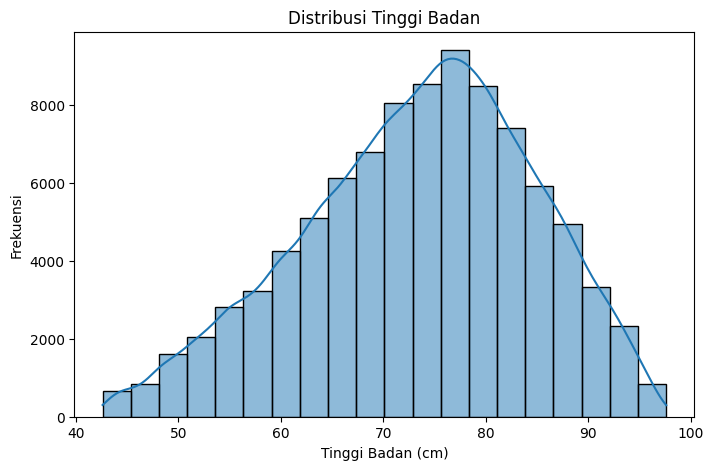

In [ ]:
# visualisasi distribusi tinggi badan
plt.figure(figsize=(8,5))

sns.histplot(
    df['tinggi_cm'],
    bins=20,
    kde=True
)

plt.title('Distribusi Tinggi Badan')
plt.xlabel('Tinggi Badan (cm)')
plt.ylabel('Frekuensi')

plt.show()

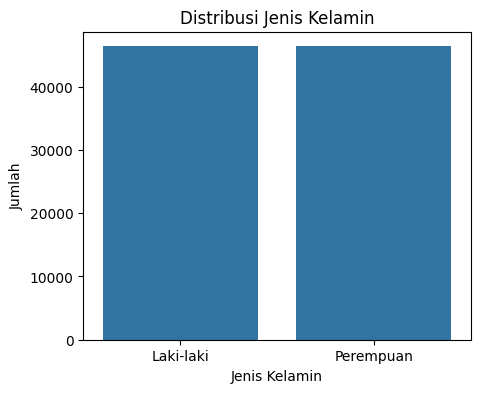

In [ ]:
# visualisasi distribusi jenis kelamin
plt.figure(figsize=(5,4))

sns.countplot(
    x='jenis_kelamin',
    data=df
)

plt.title('Distribusi Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah')

plt.show()

**Insight Exploratory Data Analysis (EDA)**

**1. Gambaran Umum Dataset**

Berdasarkan hasil` df.describe():`

- Rata-rata umur balita berada di angka 12 bulan
- Rata-rata tinggi badan sekitar 73,39 cm
- Rata-rata berat badan sekitar 9,31 kg

Insight: Sebagian besar data merepresentasikan balita usia dini dengan rata-rata tinggi dan berat badan yang masih berada pada fase pertumbuhan awal.

**2. Distribusi Status Stunting**

Hasil distribusi:

- Normal: 67.055
- Stunted: 15.039
- Severely Stunted: 5.333
- Tall: 5.265

Insight: Mayoritas balita berada pada kategori Normal, namun masih terdapat cukup banyak kasus Stunted dan Severely Stunted yang menunjukkan adanya masalah pertumbuhan pada sebagian balita.

Insight Visualisasi:Grafik distribusi menunjukkan kategori Normal mendominasi dataset dibanding kategori lainnya.

**3. Distribusi Umur Balita**

Insight: Distribusi umur balita terlihat cukup merata pada rentang usia 0–24 bulan, sehingga dataset memiliki representasi umur yang seimbang untuk dianalisis.

**4. Distribusi Tinggi Badan**

Insight: Distribusi tinggi badan membentuk pola mendekati distribusi normal dengan mayoritas balita memiliki tinggi badan pada rentang 70–80 cm.

**5. Distribusi Jenis Kelamin**

Insight: Jumlah balita laki-laki dan perempuan relatif seimbang, sehingga analisis tidak terlalu dipengaruhi oleh ketimpangan jumlah gender.

**Kesimpulan EDA**

Hasil exploratory data analysis menunjukkan bahwa dataset memiliki distribusi data yang cukup baik dan seimbang. Mayoritas balita berada pada kategori normal, namun masih ditemukan kasus stunting yang cukup signifikan sehingga analisis lebih lanjut diperlukan untuk memahami faktor-faktor yang memengaruhi kondisi tersebut.

# Feature Engineering

## Encoding Kolom Kategorikal

In [ ]:
# Menyimpan label asli sebelum diencoding
df_raw = df.copy()

# Mapping jenis kelamin: Laki-laki=1, Perempuan=0
df['jenis_kelamin_enc'] = df['jenis_kelamin'].map({'Laki-laki': 1, 'Perempuan': 0})

# Encoding wasting
df['wasting_enc'] = df['wasting'].astype('category').cat.codes
wasting_classes = dict(enumerate(df['wasting'].astype('category').cat.categories))
print('Wasting mapping:', wasting_classes)

# Encoding stunting (target)
stunting_cat = df['stunting'].astype('category')
stunting_classes = list(stunting_cat.cat.categories)
df['stunting_enc'] = stunting_cat.cat.codes
print('Stunting mapping:', dict(enumerate(stunting_classes)))

df.head()

Wasting mapping: {0: 'Normal weight', 1: 'Risk of Overweight', 2: 'Severely Underweight', 3: 'Underweight'}
Stunting mapping: {0: 'Normal', 1: 'Severely Stunted', 2: 'Stunted', 3: 'Tall'}


,jenis_kelamin,umur_bulan,tinggi_cm,berat_kg,stunting,wasting,jenis_kelamin_enc,wasting_enc,stunting_enc
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight,1,1,3
1,Laki-laki,20,77.7,8.5,Stunted,Underweight,1,3,2
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight,1,1,0
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight,0,1,1
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight,0,1,1


## Z-Score WAZ (Weight-for-Age Z-score)

WAZ dihitung berdasarkan standar WHO Child Growth Standards dengan menggunakan
Formula: **WAZ = (BB_anak − median_WHO) / SD_WHO**

| Nilai WAZ | Interpretasi |
|---|---|
| < −3 | Severely Underweight |
| −3 s/d −2 | Underweight |
| −2 s/d +2 | Normal |
| ≥ +2 | Overweight |

In [ ]:
# Weight-for-Age Z-score (WAZ)
who_waz_boys = {
     0: (3.35, 0.47),  1: (4.47, 0.55),  2: (5.57, 0.62),  3: (6.39, 0.67),
     4: (7.00, 0.71),  5: (7.51, 0.74),  6: (7.93, 0.77),  7: (8.30, 0.79),
     8: (8.62, 0.81),  9: (8.90, 0.84), 10: (9.15, 0.86), 11: (9.37, 0.88),
    12: (9.58, 0.91), 13: (9.77, 0.93), 14: (9.96, 0.95), 15:(10.14, 0.97),
    16:(10.31, 0.99), 17:(10.48, 1.01), 18:(10.65, 1.03), 19:(10.81, 1.05),
    20:(10.97, 1.07), 21:(11.13, 1.09), 22:(11.29, 1.12), 23:(11.44, 1.14),
    24:(11.60, 1.16)
}

who_waz_girls = {
     0: (3.23, 0.44),  1: (4.20, 0.52),  2: (5.12, 0.58),  3: (5.84, 0.63),
     4: (6.41, 0.66),  5: (6.87, 0.69),  6: (7.28, 0.72),  7: (7.65, 0.75),
     8: (7.98, 0.77),  9: (8.27, 0.80), 10: (8.54, 0.82), 11: (8.78, 0.84),
    12: (9.01, 0.87), 13: (9.23, 0.89), 14: (9.44, 0.91), 15: (9.64, 0.93),
    16: (9.84, 0.95), 17:(10.03, 0.97), 18:(10.21, 0.99), 19:(10.39, 1.01),
    20:(10.57, 1.03), 21:(10.74, 1.05), 22:(10.91, 1.08), 23:(11.08, 1.10),
    24:(11.25, 1.12)
}

def hitung_waz(row):
    usia = int(np.clip(row['umur_bulan'], 0, 24))
    if row['jenis_kelamin'] == 'Laki-laki':
        median, sd = who_waz_boys[usia]
    else:
        median, sd = who_waz_girls[usia]
    return (row['berat_kg'] - median) / sd

df['waz_zscore'] = df.apply(hitung_waz, axis=1)

print('Statistik WAZ Z-Score:')
print(df['waz_zscore'].describe().round(3))

Statistik WAZ Z-Score:
count    92692.000
mean         0.588
std          2.745
min         -5.068
25%         -1.769
50%          0.589
75%          2.927
max          6.000
Name: waz_zscore, dtype: float64


## BMI & Indeks Pertumbuhan Balita

In [ ]:
#BMI (Body Mass Index)

# Formula: BMI = berat_kg / (tinggi_cm / 100) ** 2
df['bmi'] = df['berat_kg'] / (df['tinggi_cm'] / 100) ** 2

print('Statistik BMI:')
print(df['bmi'].describe().round(3))

Statistik BMI:
count    92692.000
mean        17.243
std          5.215
min          3.367
25%         13.161
50%         16.927
75%         20.838
max         34.550
Name: bmi, dtype: float64


In [ ]:
# Kategori BMI WHO untuk Balita (< 5 tahun)
def kategori_bmi_balita(bmi):
    """
    Klasifikasi status gizi balita berdasarkan nilai BMI.
    Standar WHO untuk anak di bawah 5 tahun.
    """
    if bmi < 14.0:
        return 'Severely Wasted'
    elif bmi < 16.0:
        return 'Wasted'
    elif bmi <= 18.0:
        return 'Normal'
    else:
        return 'Risk of Overweight'

df['kategori_bmi'] = df['bmi'].apply(kategori_bmi_balita)

print('Distribusi Kategori BMI Balita:')
print(df['kategori_bmi'].value_counts())

Distribusi Kategori BMI Balita:
kategori_bmi
Risk of Overweight    39648
Severely Wasted       28343
Normal                12376
Wasted                12325
Name: count, dtype: int64


In [ ]:
# BMI-for-Age Z-Score (BAZ)
# Referensi median & SD BMI WHO per bulan, per jenis kelamin
# Sumber: WHO Child Growth Standards – BMI-for-age (0–24 bulan)
who_baz_boys = {
     0: (13.41, 1.55),  1: (14.94, 1.62),  2: (16.16, 1.70),  3: (16.75, 1.71),
     4: (17.11, 1.73),  5: (17.22, 1.72),  6: (17.27, 1.72),  7: (17.16, 1.71),
     8: (17.09, 1.71),  9: (16.97, 1.69), 10: (16.84, 1.68), 11: (16.74, 1.69),
    12: (16.63, 1.69), 13: (16.53, 1.69), 14: (16.43, 1.70), 15: (16.34, 1.70),
    16: (16.25, 1.71), 17: (16.17, 1.71), 18: (16.10, 1.72), 19: (16.03, 1.72),
    20: (15.97, 1.73), 21: (15.92, 1.74), 22: (15.86, 1.74), 23: (15.81, 1.75),
    24: (15.76, 1.76)
}

who_baz_girls = {
     0: (13.32, 1.53),  1: (14.60, 1.57),  2: (15.76, 1.65),  3: (16.32, 1.66),
     4: (16.65, 1.68),  5: (16.72, 1.67),  6: (16.73, 1.67),  7: (16.61, 1.67),
     8: (16.50, 1.67),  9: (16.39, 1.65), 10: (16.26, 1.64), 11: (16.14, 1.65),
    12: (16.03, 1.65), 13: (15.92, 1.65), 14: (15.82, 1.65), 15: (15.73, 1.66),
    16: (15.64, 1.66), 17: (15.55, 1.66), 18: (15.47, 1.67), 19: (15.40, 1.68),
    20: (15.33, 1.68), 21: (15.27, 1.69), 22: (15.21, 1.70), 23: (15.15, 1.71),
    24: (15.10, 1.72)
}

def hitung_baz(row):
    """Hitung BMI-for-Age Z-score per baris berdasarkan standar WHO."""
    usia = int(np.clip(row['umur_bulan'], 0, 24))
    bmi  = row['bmi']
    if row['jenis_kelamin'] == 'Laki-laki':
        median, sd = who_baz_boys[usia]
    else:
        median, sd = who_baz_girls[usia]
    return (bmi - median) / sd

df['baz_zscore'] = df.apply(hitung_baz, axis=1)

print('Statistik BAZ Z-Score:')
print(df['baz_zscore'].describe().round(3))

Statistik BAZ Z-Score:
count    92692.000
mean         0.725
std          3.083
min         -6.505
25%         -1.702
50%          0.527
75%          2.828
max         11.823
Name: baz_zscore, dtype: float64


In [ ]:
# Weight-to-Height Ratio (WHR)
# Indikator sederhana proporsi berat terhadap tinggi
df['weight_height_ratio'] = df['berat_kg'] / df['tinggi_cm']

print('Statistik Weight-to-Height Ratio:')
print(df['weight_height_ratio'].describe().round(3))

Statistik Weight-to-Height Ratio:
count    92692.000
mean         0.125
std          0.037
min          0.018
25%          0.097
50%          0.125
75%          0.154
max          0.224
Name: weight_height_ratio, dtype: float64


## Preview hasil feature engineering


In [ ]:
# Preview hasil feature engineering
print('Preview hasil feature engineering:')
df[[
    'umur_bulan', 'tinggi_cm', 'berat_kg', 'jenis_kelamin', 'stunting',
    'waz_zscore', 'baz_zscore',
    'bmi', 'kategori_bmi', 'weight_height_ratio',
]].head(10)

Preview hasil feature engineering:


,umur_bulan,tinggi_cm,berat_kg,jenis_kelamin,stunting,waz_zscore,baz_zscore,bmi,kategori_bmi,weight_height_ratio
0,19,91.6,13.3,Laki-laki,Tall,2.371429,-0.103984,15.851147,Wasted,0.145197
1,20,77.7,8.5,Laki-laki,Stunted,-2.308411,-1.092968,14.079165,Wasted,0.109395
2,10,79.0,10.3,Laki-laki,Normal,1.337209,-0.200140,16.503765,Normal,0.130380
3,2,50.3,8.3,Perempuan,Severely Stunted,5.482759,10.330398,32.805157,Risk of Overweight,0.165010
4,5,56.4,10.9,Perempuan,Severely Stunted,5.840580,10.506817,34.266385,Risk of Overweight,0.193262
5,11,76.3,5.9,Laki-laki,Normal,-3.943182,-3.908571,10.134514,Severely Wasted,0.077326
6,16,80.7,9.9,Laki-laki,Normal,-0.414141,-0.613123,15.201559,Wasted,0.122677
7,15,72.6,6.5,Perempuan,Normal,-3.376344,-2.046875,12.332187,Severely Wasted,0.089532
8,18,78.4,15.6,Perempuan,Normal,5.444444,5.934162,25.380050,Risk of Overweight,0.198980
9,2,63.4,7.0,Laki-laki,Normal,2.306452,0.738142,17.414841,Normal,0.110410


## Ringkasan Fitur

In [ ]:
print('=== Ringkasan Fitur ===')
print(f"Fitur asli    : {['umur_bulan','tinggi_cm','berat_kg','jenis_kelamin','stunting','wasting']}")
print(f"Fitur encoded : jenis_kelamin_enc, wasting_enc, stunting_enc")
print(f"Fitur z-score : waz_zscore, baz_zscore")
print(f"Fitur BMI     : bmi, kategori_bmi, weight_height_ratio")
print(f"\nTotal kolom : {df.shape[1]}")
print(f"Total baris : {df.shape[0]:,}")

=== Ringkasan Fitur ===
Fitur asli    : ['umur_bulan', 'tinggi_cm', 'berat_kg', 'jenis_kelamin', 'stunting', 'wasting']
Fitur encoded : jenis_kelamin_enc, wasting_enc, stunting_enc
Fitur z-score : waz_zscore, baz_zscore
Fitur BMI     : bmi, kategori_bmi, weight_height_ratio

Total kolom : 14
Total baris : 92,692


# Data Dictionary

In [ ]:
# ============================================================
# DATA DICTIONARY
# ============================================================

data_dictionary = {

    # A. Kolom Asli (Raw Features)
    'jenis_kelamin': {
        'tipe'      : 'object (kategorikal)',
        'nilai'     : ['Laki-laki', 'Perempuan'],
        'deskripsi' : 'Jenis kelamin balita'
    },
    'umur_bulan': {
        'tipe'      : 'int',
        'nilai'     : '0 – 24',
        'deskripsi' : 'Usia balita dalam satuan bulan'
    },
    'tinggi_cm': {
        'tipe'      : 'float',
        'nilai'     : 'kontinu (cm)',
        'deskripsi' : 'Tinggi badan balita'
    },
    'berat_kg': {
        'tipe'      : 'float',
        'nilai'     : 'kontinu (kg)',
        'deskripsi' : 'Berat badan balita'
    },
    'stunting': {
        'tipe'      : 'object (kategorikal)',
        'nilai'     : ['Normal', 'Stunted', 'Severely Stunted', 'Tall'],
        'deskripsi' : 'Status stunting balita berdasarkan standar WHO (variabel target)'
    },
    'wasting': {
        'tipe'      : 'object (kategorikal)',
        'nilai'     : ['Normal weight', 'Underweight', 'Severely Underweight', 'Risk of Overweight'],
        'deskripsi' : 'Status wasting (kurus) balita berdasarkan standar WHO'
    },

    # B. Kolom Hasil Encoding
    'jenis_kelamin_enc': {
        'tipe'      : 'int',
        'nilai'     : {0: 'Perempuan', 1: 'Laki-laki'},
        'deskripsi' : 'Encoding biner jenis kelamin'
    },
    'wasting_enc': {
        'tipe'      : 'int',
        'nilai'     : '0 – 3 (urutan abjad kategori wasting)',
        'deskripsi' : 'Encoding ordinal kategori wasting'
    },
    'stunting_enc': {
        'tipe'      : 'int',
        'nilai'     : '0 – 3 (urutan abjad kategori stunting)',
        'deskripsi' : 'Encoding ordinal status stunting — digunakan sebagai y pada modeling'
    },

    # C. Z-Score Antropometri (Standar WHO)
    'waz_zscore': {
        'tipe'      : 'float',
        'formula'   : '(berat_kg - median_WHO) / SD_WHO',
        'interpretasi': {
            '< -3'      : 'Severely Underweight',
            '-3 s/d -2' : 'Underweight',
            '-2 s/d +2' : 'Normal',
            '>= +2'     : 'Overweight'
        },
        'deskripsi' : 'Weight-for-Age Z-Score — indikator status gizi berdasarkan berat'
    },
    'baz_zscore': {
        'tipe'      : 'float',
        'formula'   : '(bmi - median_BMI_WHO) / SD_BMI_WHO',
        'interpretasi': {
            '< -3'      : 'Severely Wasted',
            '-3 s/d -2' : 'Wasted',
            '-2 s/d +2' : 'Normal',
            '>= +2'     : 'Risk of Overweight'
        },
        'deskripsi' : 'BMI-for-Age Z-Score — proporsionalitas berat-tinggi disesuaikan usia & gender'
    },

    # D. Fitur BMI & Proporsi Tubuh
    'bmi': {
        'tipe'      : 'float',
        'formula'   : 'berat_kg / (tinggi_cm / 100) ** 2',
        'satuan'    : 'kg/m²',
        'deskripsi' : 'Body Mass Index — perlu dikombinasikan dengan usia untuk interpretasi klinis'
    },
    'kategori_bmi': {
        'tipe'      : 'object (kategorikal)',
        'nilai'     : {
            'Severely Wasted'    : 'BMI < 14.0  → Gizi buruk akut',
            'Wasted'             : 'BMI 14–15.9 → Gizi kurang / kurus',
            'Normal'             : 'BMI 16–18.0 → Gizi baik',
            'Risk of Overweight' : 'BMI > 18.0  → Berisiko kelebihan gizi'
        },
        'deskripsi' : 'Kategori BMI balita berdasarkan threshold WHO'
    },
    'weight_height_ratio': {
        'tipe'      : 'float',
        'formula'   : 'berat_kg / tinggi_cm',
        'satuan'    : 'kg/cm',
        'deskripsi' : 'Rasio berat terhadap tinggi — proxy sederhana proporsionalitas tubuh'
    },
}

# dictionary secara terstruktur
print("=" * 60)
print("  DATA DICTIONARY – AnakSehat AI")
print("=" * 60)

sections = {
    'A. Kolom Asli (Raw Features)'           : ['jenis_kelamin', 'umur_bulan', 'tinggi_cm', 'berat_kg', 'stunting', 'wasting'],
    'B. Kolom Hasil Encoding'                 : ['jenis_kelamin_enc', 'wasting_enc', 'stunting_enc'],
    'C. Z-Score Antropometri (Standar WHO)'   : ['waz_zscore', 'baz_zscore'],
    'D. Fitur BMI & Proporsi Tubuh'    : ['bmi', 'kategori_bmi', 'weight_height_ratio'],
}

for section, cols in sections.items():
    print(f"\n{'─' * 60}")
    print(f"  {section}")
    print(f"{'─' * 60}")
    for col in cols:
        info = data_dictionary[col]
        print(f"\n  {col}")
        for k, v in info.items():
            if isinstance(v, dict):
                print(f"     {k}:")
                for kk, vv in v.items():
                    print(f"       • {kk}: {vv}")
            else:
                print(f"     {k}: {v}")

print(f"\n{'=' * 60}")
print(f"  Total fitur terdokumentasi : {len(data_dictionary)}")
print(f"{'=' * 60}")

  DATA DICTIONARY – AnakSehat AI

────────────────────────────────────────────────────────────
  A. Kolom Asli (Raw Features)
────────────────────────────────────────────────────────────

  jenis_kelamin
     tipe: object (kategorikal)
     nilai: ['Laki-laki', 'Perempuan']
     deskripsi: Jenis kelamin balita

  umur_bulan
     tipe: int
     nilai: 0 – 24
     deskripsi: Usia balita dalam satuan bulan

  tinggi_cm
     tipe: float
     nilai: kontinu (cm)
     deskripsi: Tinggi badan balita

  berat_kg
     tipe: float
     nilai: kontinu (kg)
     deskripsi: Berat badan balita

  stunting
     tipe: object (kategorikal)
     nilai: ['Normal', 'Stunted', 'Severely Stunted', 'Tall']
     deskripsi: Status stunting balita berdasarkan standar WHO (variabel target)

  wasting
     tipe: object (kategorikal)
     nilai: ['Normal weight', 'Underweight', 'Severely Underweight', 'Risk of Overweight']
     deskripsi: Status wasting (kurus) balita berdasarkan standar WHO

─────────────────────

# Simpan dataset hasil final ke CSV

In [ ]:
# Simpan dataset hasil feature engineering ke CSV
df.to_csv('data_final_AnakSehat.csv', index=False)
print('Dataset berhasil disimpan!')
print(f'Shape: {df.shape}')
print(f'Kolom: {list(df.columns)}')

Dataset berhasil disimpan!
Shape: (92692, 14)
Kolom: ['jenis_kelamin', 'umur_bulan', 'tinggi_cm', 'berat_kg', 'stunting', 'wasting', 'jenis_kelamin_enc', 'wasting_enc', 'stunting_enc', 'waz_zscore', 'bmi', 'kategori_bmi', 'baz_zscore', 'weight_height_ratio']


# Visualization & Explanatory Analysis

## Pertanyaan 1:

Pada kelompok usia serta jenis kelamin manakah yang memiliki presentase stunting tertinggi ditemukan pada balita dalam rentang usia 0 sampai 24 bulan?

In [ ]:
# Mengelompokan umur
bins = [0, 6, 12, 18, 24]
labels = ['0-6', '7-12', '13-18', '19-24']

df['kelompok_usia'] = pd.cut(
    df['umur_bulan'],
    bins=bins,
    labels=labels
)

In [ ]:
# Menghitung presentase
stunting_age_gender = pd.crosstab(
    [df['kelompok_usia'], df['jenis_kelamin']],
    df['stunting'],
    normalize='index'
) * 100

stunting_age_gender

stunting                        Normal  Severely Stunted    Stunted      Tall
kelompok_usia jenis_kelamin                                                  
0-6           Laki-laki      72.605011          6.908622  14.185704  6.300663
              Perempuan      73.033088          6.268382  14.485294  6.213235
7-12          Laki-laki      73.217002          6.022371  14.496644  6.263982
              Perempuan      73.704860          5.804726  14.783772  5.706643
13-18         Laki-laki      73.096763          5.478477  15.546069  5.878691
              Perempuan      74.556266          5.351438  14.820731  5.271565
19-24         Laki-laki      70.779506          4.947711  19.412954  4.859830
              Perempuan      68.255650          4.766949  22.298729  4.678672

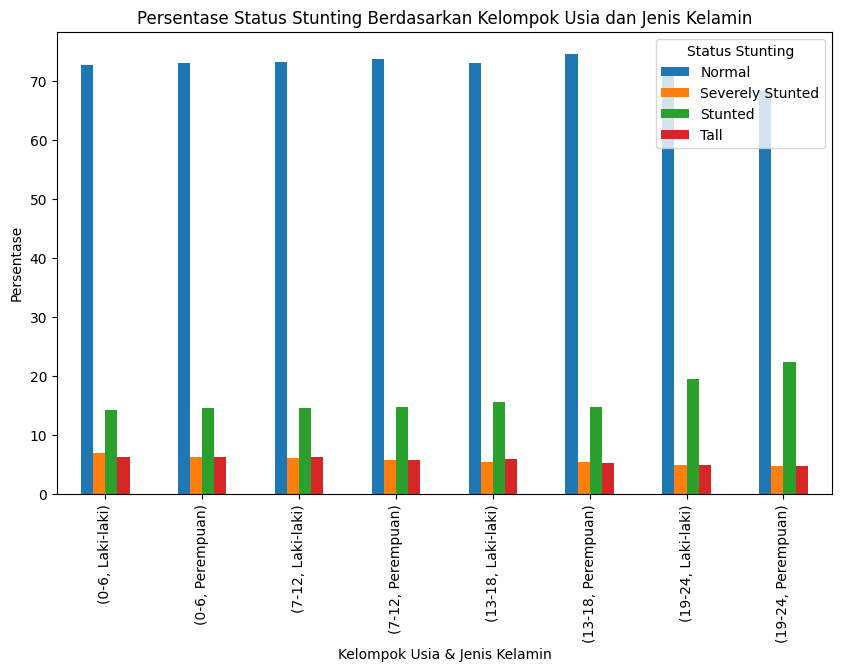

In [ ]:
# Visualisasi
stunting_age_gender.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Persentase Status Stunting Berdasarkan Kelompok Usia dan Jenis Kelamin')
plt.ylabel('Persentase')
plt.xlabel('Kelompok Usia & Jenis Kelamin')

plt.legend(title='Status Stunting')

plt.show()

**Hasil Analisis**

Berdasarkan hasil perhitungan persentase dan visualisasi:

- Kelompok usia 19–24 bulan perempuan memiliki persentase Stunted tertinggi, yaitu sekitar 22,30%.
- Pada kelompok laki-laki usia 19–24 bulan, persentase stunting juga cukup tinggi, yaitu sekitar 19,41%.
- Persentase Severely Stunted cenderung lebih tinggi pada kelompok usia dini (0–6 bulan), kemudian menurun seiring bertambahnya usia.

**Insight**: Risiko stunting cenderung meningkat pada balita usia 19–24 bulan, terutama pada anak perempuan. Hal ini menunjukkan bahwa periode menjelang usia 2 tahun merupakan fase kritis pertumbuhan anak yang memerlukan perhatian khusus terkait asupan gizi dan pola makan.

## Pertanyaan 2:

Bagaimana distribusi dan karakteristik tinggi badan, berat badan, usia, serta jenis kelamin pada masing-masing kategori status stunting balita usia 0–24 bulan?

In [ ]:
# Cek statistik deskriptif
df.groupby('stunting')[
    ['umur_bulan', 'tinggi_cm', 'berat_kg']
].describe()

umur_bulan                                                   \
                      count       mean       std  min  25%   50%   75%   max   
stunting                                                                       
Normal              67055.0  12.068928  7.104493  0.0  6.0  12.0  18.0  24.0   
Severely Stunted     5333.0  11.247703  7.209175  0.0  5.0  11.0  17.0  24.0   
Stunted             15039.0  13.172751  7.393600  0.0  7.0  14.0  20.0  24.0   
Tall                 5265.0  11.462868  7.081068  0.0  5.0  11.0  17.0  24.0   

                 tinggi_cm             ...             berat_kg            \
                     count       mean  ...   75%   max    count      mean   
stunting                               ...                                  
Normal             67055.0  74.703357  ...  83.1  96.6  67055.0  9.293006   
Severely Stunted    5333.0  64.172492  ...  72.0  78.3   5333.0  9.001125   
Stunted            15039.0  68.366740  ...  76.3  82.8  15039.0  9.603059   
Tall                5265.0  80.419221  ...  89.7  97.6   5265.0  9.133219   

                                                       
                       std  min  25%  50%   75%   max  
stunting                                               
Normal            3.272842  1.0  6.9  9.2  11.7  17.2  
Severely Stunted  3.324713  1.0  6.6  8.9  11.5  17.1  
Stunted           3.318509  1.0  7.2  9.5  12.1  17.2  
Tall              3.278709  1.1  6.8  9.0  11.6  17.2  

[4 rows x 24 columns]

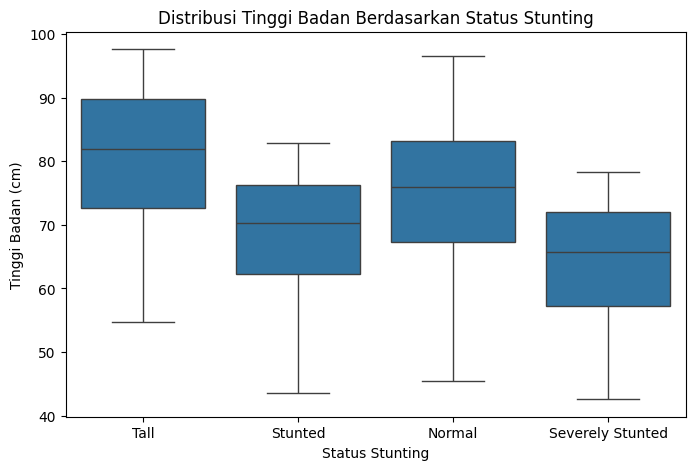

In [ ]:
# Distribusi Tinggi Badan per Kategori Stunting
plt.figure(figsize=(8,5))

sns.boxplot(
    x='stunting',
    y='tinggi_cm',
    data=df
)

plt.title('Distribusi Tinggi Badan Berdasarkan Status Stunting')
plt.xlabel('Status Stunting')
plt.ylabel('Tinggi Badan (cm)')

plt.show()

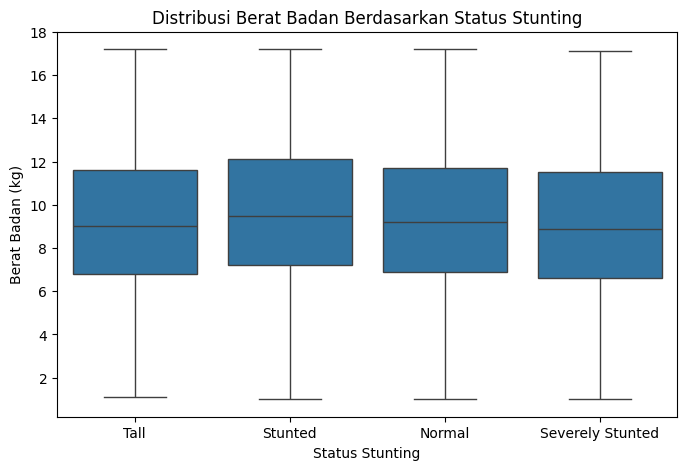

In [ ]:
# Distribusi Berat Badan per Kategori
plt.figure(figsize=(8,5))

sns.boxplot(
    x='stunting',
    y='berat_kg',
    data=df
)

plt.title('Distribusi Berat Badan Berdasarkan Status Stunting')
plt.xlabel('Status Stunting')
plt.ylabel('Berat Badan (kg)')

plt.show()

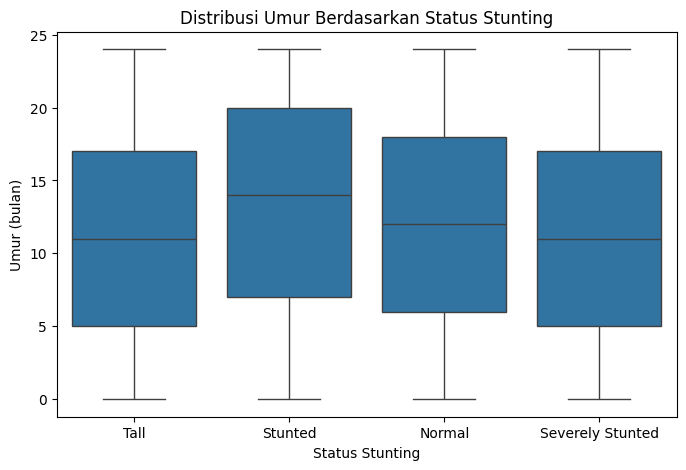

In [ ]:
# Distribusi Umur per Kategori
plt.figure(figsize=(8,5))

sns.boxplot(
    x='stunting',
    y='umur_bulan',
    data=df
)

plt.title('Distribusi Umur Berdasarkan Status Stunting')
plt.xlabel('Status Stunting')
plt.ylabel('Umur (bulan)')

plt.show()

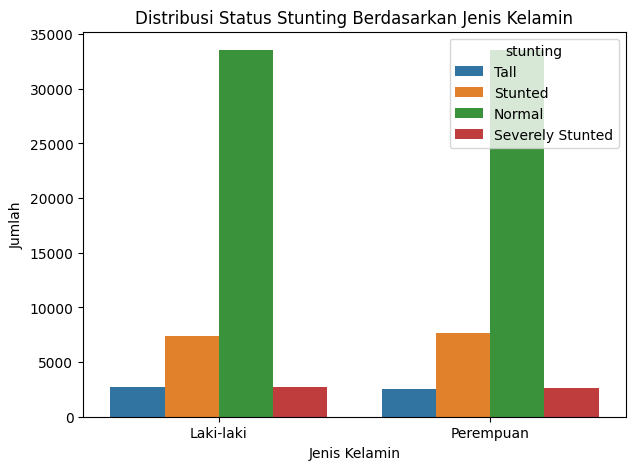

In [ ]:
# Distribusi Jenis Kelamin
plt.figure(figsize=(7,5))

sns.countplot(
    x='jenis_kelamin',
    hue='stunting',
    data=df
)

plt.title('Distribusi Status Stunting Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah')

plt.show()

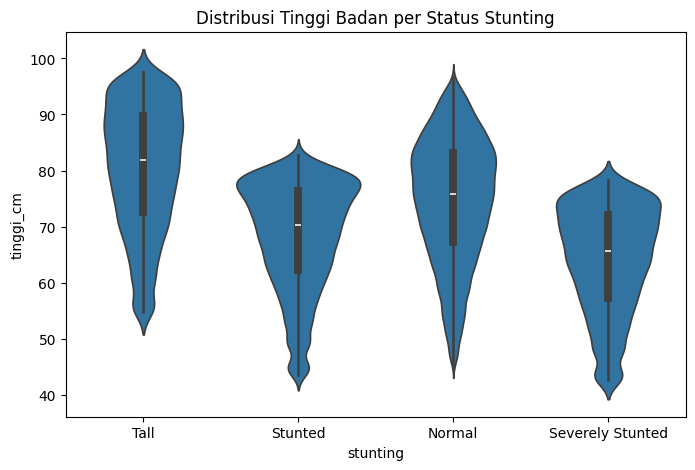

In [ ]:
# Violin plot
plt.figure(figsize=(8,5))

sns.violinplot(
    x='stunting',
    y='tinggi_cm',
    data=df
)

plt.title('Distribusi Tinggi Badan per Status Stunting')

plt.show()

**Hasil Analisis**

1. Karakteristik Tinggi Badan

Berdasarkan hasil statistik dan visualisasi:

- Kategori Tall memiliki rata-rata tinggi badan tertinggi, yaitu sekitar 80,42 cm
- Kategori Severely Stunted memiliki rata-rata tinggi badan terendah, yaitu sekitar 64,17 cm
- Kategori Stunted juga memiliki tinggi badan lebih rendah dibanding kategori Normal

Insight: Tinggi badan menjadi indikator utama dalam penentuan status stunting. Semakin rendah tinggi badan balita, maka semakin tinggi risiko mengalami stunting.

2. Karakteristik Berat Badan

- Rata-rata berat badan pada seluruh kategori relatif tidak memiliki perbedaan yang terlalu jauh
- Kategori Stunted memiliki rata-rata berat badan sedikit lebih tinggi dibanding kategori lainnya

Insight: Berat badan tidak menunjukkan perbedaan yang signifikan antar kategori stunting dibandingkan tinggi badan, sehingga tinggi badan lebih dominan dalam menggambarkan kondisi stunting.

3. Karakteristik Umur

- Kategori Stunted memiliki rata-rata umur tertinggi, yaitu sekitar 13 bulan
- Kategori lainnya berada di sekitar usia 11–12 bulan

Insight: Risiko stunting cenderung meningkat seiring bertambahnya usia balita, terutama mendekati usia 2 tahun.

4. Distribusi Jenis Kelamin

- Jumlah balita laki-laki dan perempuan pada setiap kategori stunting terlihat relatif seimbang
- Namun kategori Stunted sedikit lebih banyak ditemukan pada balita perempuan

Insight: Tidak terdapat perbedaan yang terlalu signifikan berdasarkan jenis kelamin, meskipun balita perempuan menunjukkan jumlah kasus stunting yang sedikit lebih tinggi.

5. Distribusi Data Berdasarkan Visualisasi

Insight Boxplot & Violin Plot:
- Kategori Severely Stunted memiliki persebaran tinggi badan paling rendah
- Kategori Tall menunjukkan distribusi tinggi badan paling tinggi dan lebih konsisten
- Persebaran tinggi badan antar kategori terlihat cukup jelas dan terpisah

Insight: Visualisasi menunjukkan bahwa tinggi badan memiliki hubungan yang kuat terhadap klasifikasi status stunting.

**Kesimpulan**

Hasil analisis menunjukkan bahwa tinggi badan merupakan faktor yang paling membedakan kategori status stunting. Balita dengan kategori Severely Stunted memiliki tinggi badan paling rendah, sedangkan kategori Tall memiliki tinggi badan paling tinggi. Selain itu, risiko stunting cenderung meningkat pada usia yang lebih besar, sementara distribusi jenis kelamin relatif seimbang pada setiap kategori stunting.

## Pertanyaan 3:

Bagaimana distribusi jumlah kasus stunting pada setiap kelompok usia dan jenis kelamin balita usia 0–24 bulan dalam dataset AnakSehat AI?

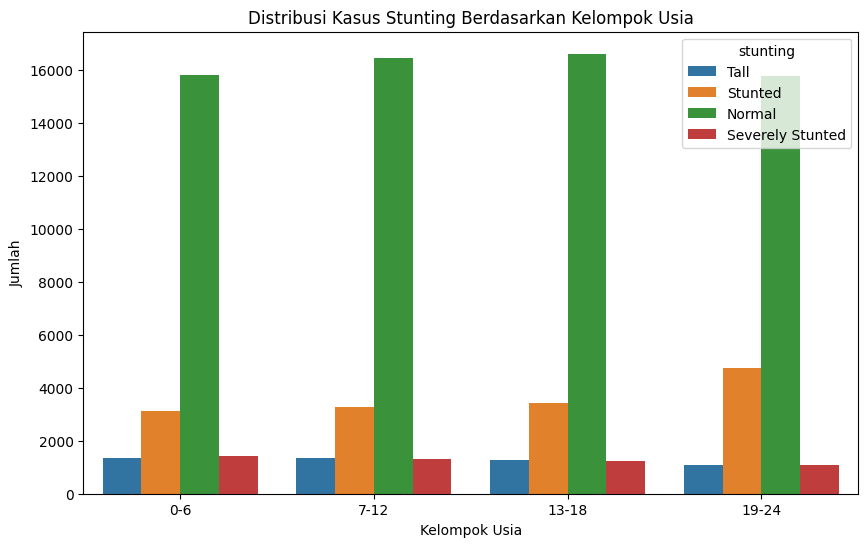

In [ ]:
# Visualisasi distribusi by umur
plt.figure(figsize=(10,6))

sns.countplot(
    x='kelompok_usia',
    hue='stunting',
    data=df
)

plt.title('Distribusi Kasus Stunting Berdasarkan Kelompok Usia')

plt.xlabel('Kelompok Usia')
plt.ylabel('Jumlah')

plt.show()

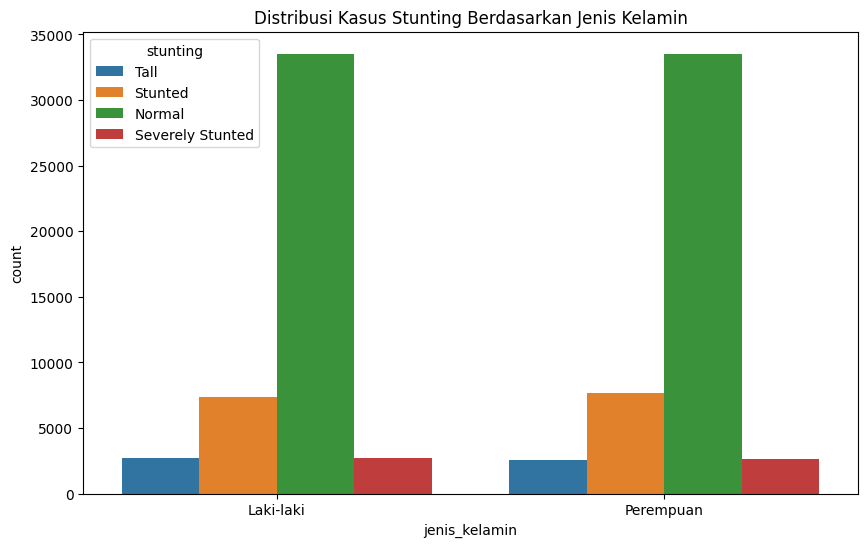

In [ ]:
# Visualisasi distribusi by jenis kelamin
plt.figure(figsize=(10,6))

sns.countplot(
    x='jenis_kelamin',
    hue='stunting',
    data=df
)

plt.title('Distribusi Kasus Stunting Berdasarkan Jenis Kelamin')

plt.show()

**Hasil Analisis**

1. Distribusi Kasus Berdasarkan Kelompok Usia

Berdasarkan visualisasi:

- Kategori Normal mendominasi pada seluruh kelompok usia
- Jumlah kasus Stunted meningkat seiring bertambahnya usia balita
- Kelompok usia 19–24 bulan memiliki jumlah kasus stunting paling tinggi dibanding kelompok usia lainnya
- Kasus Severely Stunted cenderung lebih rendah dan relatif stabil di setiap kelompok usia

Insight: Risiko stunting terlihat meningkat pada balita usia yang lebih besar, terutama pada rentang usia 19–24 bulan yang menunjukkan jumlah kasus stunting tertinggi.

2. Distribusi Kasus Berdasarkan Jenis Kelamin

Berdasarkan grafik:

- Distribusi status stunting antara laki-laki dan perempuan terlihat relatif seimbang
- Namun jumlah kasus Stunted pada perempuan sedikit lebih tinggi dibanding laki-laki
- Kategori Normal tetap menjadi kategori terbesar pada kedua gender

Insight: Jenis kelamin tidak menunjukkan perbedaan yang terlalu signifikan terhadap distribusi stunting, meskipun balita perempuan memiliki jumlah kasus stunting sedikit lebih banyak.

**Kesimpulan**

Mayoritas balita dalam dataset berada pada kategori normal. Namun, jumlah kasus stunting meningkat pada kelompok usia yang lebih besar, terutama usia 19–24 bulan. Selain itu, distribusi kasus antara laki-laki dan perempuan relatif seimbang dengan sedikit dominasi kasus stunting pada balita perempuan.

## Pertanyaan 4:

Bagaimana hubungan antara tinggi badan, berat badan, dan usia terhadap kategori status stunting balita berdasarkan hasil visualisasi data pada dataset AnakSehat AI?

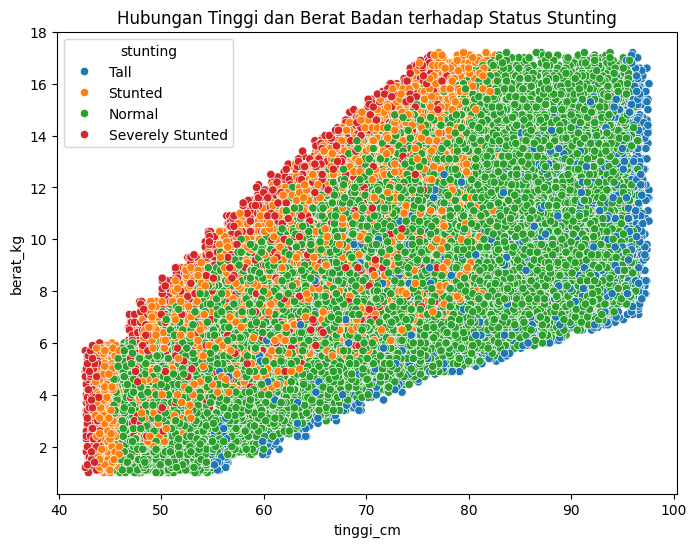

In [ ]:
# Visualisasi tinggi vs berat
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='tinggi_cm',
    y='berat_kg',
    hue='stunting',
    data=df
)

plt.title('Hubungan Tinggi dan Berat Badan terhadap Status Stunting')

plt.show()

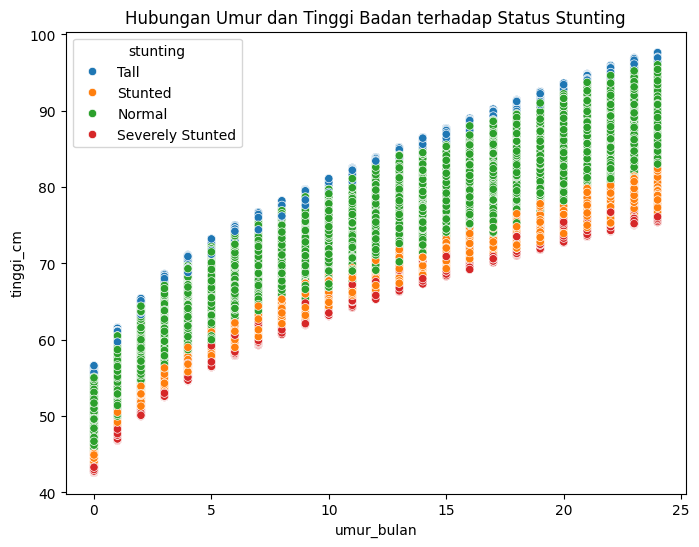

In [ ]:
# Visualisasi tinggi vs umur
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='umur_bulan',
    y='tinggi_cm',
    hue='stunting',
    data=df
)

plt.title('Hubungan Umur dan Tinggi Badan terhadap Status Stunting')

plt.show()

**Hasil Analisis**

1. Hubungan Tinggi Badan dan Berat Badan terhadap Status Stunting
Berdasarkan scatterplot:


    - Balita dengan kategori Normal dan Tall cenderung memiliki tinggi badan dan berat badan yang lebih tinggi

    - Kategori Stunted dan Severely Stunted lebih banyak berada pada area tinggi badan yang lebih rendah

    - Semakin tinggi badan balita, umumnya berat badan juga ikut meningkat


Insight: Terdapat hubungan positif antara tinggi badan dan berat badan. Balita dengan tinggi badan rendah cenderung lebih berisiko mengalami stunting.


2. Hubungan Umur dan Tinggi Badan terhadap Status Stunting
Berdasarkan visualisasi:

    - Tinggi badan meningkat seiring bertambahnya umur balita
    - Kategori Tall selalu berada pada posisi tinggi badan tertinggi di setiap usia
    - Kategori Severely Stunted consistently memiliki tinggi badan paling rendah pada setiap kelompok umur
    - Kategori Normal berada di antara Tall dan Stunted


Insight:

Umur memiliki hubungan positif terhadap tinggi badan, namun balita dengan status stunting tetap menunjukkan pertumbuhan tinggi badan yang lebih rendah dibanding kategori normal pada usia yang sama.


Insight Utama:

Tinggi badan merupakan indikator yang paling kuat dalam membedakan kategori status stunting. Semakin rendah tinggi badan balita dibanding standar usianya, maka semakin tinggi risiko mengalami stunting atau severely stunted.


**Kesimpulan**

Hasil visualisasi menunjukkan adanya hubungan yang jelas antara usia, tinggi badan, dan berat badan terhadap status stunting. Pertumbuhan tinggi badan meningkat seiring bertambahnya usia, namun balita dengan kategori stunting memiliki pola pertumbuhan yang lebih rendah dibanding balita normal. Selain itu, tinggi badan dan berat badan memiliki hubungan positif dalam menggambarkan kondisi pertumbuhan balita.


## Pertanyaan 5:

Bagaimana perbedaan pola pertumbuhan tinggi badan dan berat badan antara balita normal, stunted, dan severely stunted usia 0–24 bulan berdasarkan dataset AnakSehat AI?

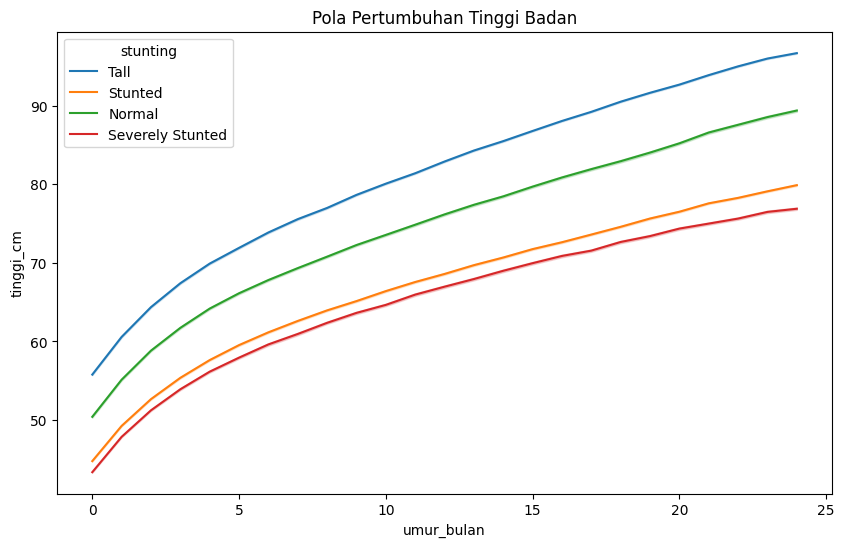

In [ ]:
# Visualisasi tinggi badan
plt.figure(figsize=(10,6))

sns.lineplot(
    x='umur_bulan',
    y='tinggi_cm',
    hue='stunting',
    data=df
)

plt.title('Pola Pertumbuhan Tinggi Badan')

plt.show()

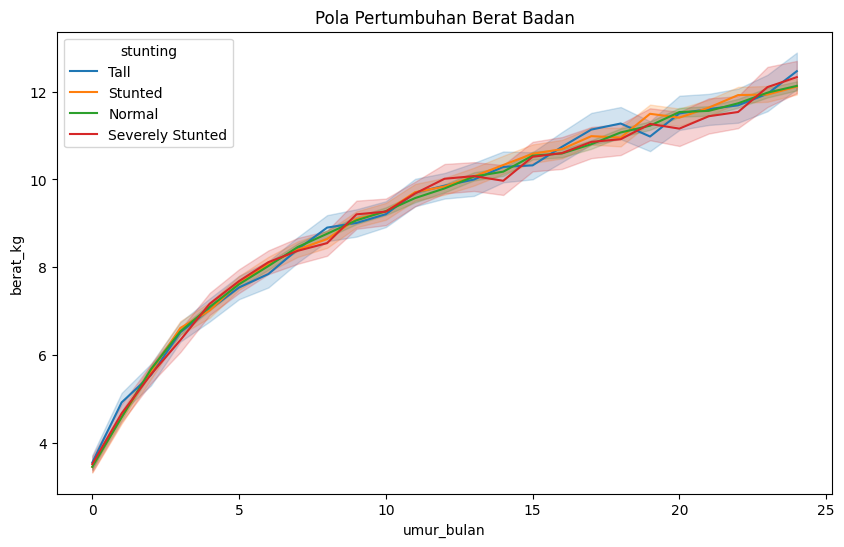

In [ ]:
# Visualisasi berat badan
plt.figure(figsize=(10,6))

sns.lineplot(
    x='umur_bulan',
    y='berat_kg',
    hue='stunting',
    data=df
)

plt.title('Pola Pertumbuhan Berat Badan')

plt.show()

**Hasil Analisis**

1. Pola Pertumbuhan Tinggi Badan

Berdasarkan visualisasi lineplot:

- Seluruh kategori mengalami peningkatan tinggi badan seiring bertambahnya usia
- Kategori Tall memiliki pola pertumbuhan tinggi badan paling tinggi pada setiap usia
- Kategori Normal berada di tengah dengan pertumbuhan yang stabil
- Kategori Stunted dan Severely Stunted memiliki pertumbuhan tinggi badan lebih lambat dibanding kategori normal
- Kategori Severely Stunted menunjukkan tinggi badan paling rendah pada seluruh rentang usia

Insight:Perbedaan pola pertumbuhan tinggi badan terlihat sangat jelas antar kategori stunting. Semakin parah kondisi stunting, semakin rendah pola pertumbuhan tinggi badan balita.

2. Pola Pertumbuhan Berat Badan

Berdasarkan visualisasi:

- Berat badan seluruh kategori meningkat secara bertahap seiring bertambahnya usia
- Perbedaan berat badan antar kategori tidak terlalu jauh dibanding tinggi badan
- Kurva berat badan kategori Normal, Stunted, dan Severely Stunted terlihat cukup berdekatan

Insight:  
Berat badan tidak menunjukkan perbedaan pola yang terlalu signifikan antar kategori stunting, sehingga tinggi badan menjadi indikator yang lebih kuat dalam membedakan kondisi stunting.

Insight Utama:

Tinggi badan menjadi indikator utama dalam melihat perbedaan pola pertumbuhan balita normal dan balita stunting. Balita dengan kategori stunted dan severely stunted mengalami pertumbuhan tinggi badan yang lebih lambat dibanding balita normal pada usia yang sama.

**Kesimpulan**

Hasil analisis menunjukkan bahwa pola pertumbuhan tinggi badan memiliki perbedaan yang jelas antar kategori status stunting, sedangkan pola pertumbuhan berat badan cenderung lebih mirip. Hal ini menunjukkan bahwa stunting lebih berkaitan dengan gangguan pertumbuhan tinggi badan kronis dibandingkan berat badan.